In [11]:
import sys

package_path = ".."
if package_path not in sys.path:
    sys.path.append(package_path)

In [12]:
%reload_ext autoreload
%autoreload 2

In [13]:
import os
import sys
from pathlib import Path

package_path: str = ".."
if package_path not in sys.path:
    sys.path.append(package_path)
    print(f"Added {Path(package_path).resolve()} to sys.path")

working_dir: Path = Path.cwd()
while working_dir.name != "QoraFlow":
    working_dir = working_dir.parent
os.chdir(working_dir)
print(f"Current working directory set to {working_dir.resolve()}")

Current working directory set to /home/hxpp-admin/Desktop/sogang260903/QoraFlow


In [14]:
import matplotlib.pyplot as plt
import numpy as np

from QoraFlow.config import ConfigManager, ExpConfig
from QoraFlow.logger import Logger, setup_logger

ConfigManager.initialize("config.yaml")
config: ExpConfig = ConfigManager.load_config()
logger: Logger = setup_logger()

In [16]:
import zarr

run_n = 22

file = config.path.load_dir / "archive" / f"run{run_n:05}" / "scan00001" / "raw.zarr"
root = zarr.open(file, mode='r')

det = root['det-eh1-jungfrau2']
shape = det.shape
chunks = det.chunks

print(shape, chunks)

(1, 2100, 512, 1024) (1, 1, 64, 64)


In [17]:
for key in root.keys():
    print(key, root[key].shape)
root["index"][0]

det-eh1-jungfrau2 (1, 2100, 512, 1024)
index (1, 2100, 2)
qbpm_oh1_qbpm2 (1, 2100, 4, 32768)
qbpm_eh1_qbpm1 (1, 2100, 4, 32768)


array([[1788439993087162,            34200],
       [1788439993103809,            34206],
       [1788439993120455,            34212],
       ...,
       [1788440028032505,            46782],
       [1788440028049152,            46788],
       [1788440028065798,            46794]], shape=(2100, 2))

In [ ]:
print(f"Number of missing frame: {np.sum(np.isnan(det[0, :, 0, 0]))}")

Number of missing frame: 3


In [ ]:
print("Number of shape", np.prod(shape))

Number of shape 1101004800


In [ ]:
img = det[0, :10].mean(axis=0) # Consider the chunks. You can fetch this data in <1 second.
print(img.shape)

(512, 1024)


In [ ]:
img.mean()

np.float32(0.028016279)

In [ ]:
safe_img = np.nanmean(det[0, :10], axis=0)

/tmp/ipykernel_2294880/3346651274.py:6: RuntimeWarning: invalid value encountered in log
  axis.imshow(np.log(safe_img))


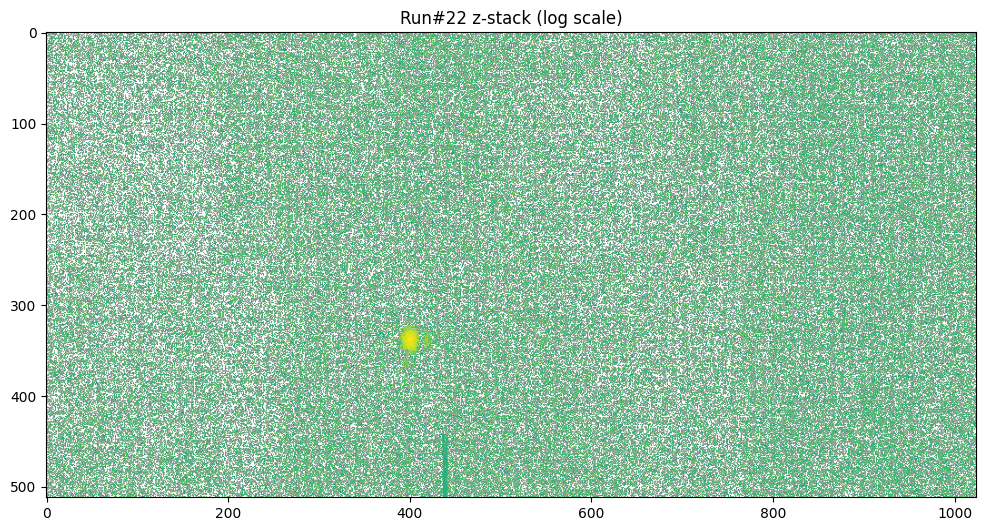

In [ ]:
import matplotlib.pyplot as plt

fig, axis = plt.subplots(1, 1, figsize=(12, 9))

axis.set_title("Run#22 z-stack (log scale)")
axis.imshow(np.log(safe_img))

In [ ]:
from roi_rectangle import RoiRectangle

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
rect = RoiRectangle(y1=280, y2=400, x1=340, x2=460)
chunked_data_in_roi = rect.shape(det[0]) # Consider the chunks. You can draw this in seconds.
img = np.nanmean(chunked_data_in_roi, axis=0)
ax.imshow(np.log(img), cmap="viridis")
ax.set_title("ROI Images mean")

NameError: name 'plt' is not defined

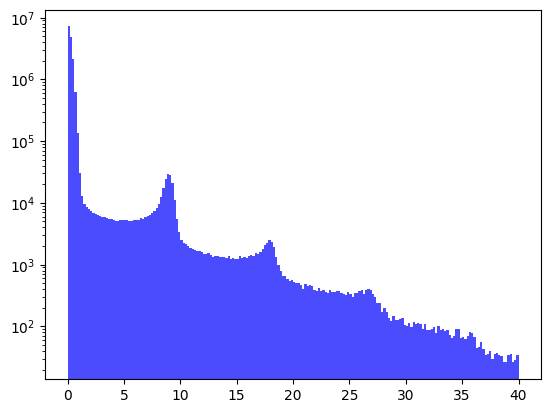

In [ ]:
vals = chunked_data_in_roi[~np.isnan(chunked_data_in_roi)]    # Most of interesting photons are only in the ROI. This take less than a second.

hist, bin_edges = np.histogram(vals.ravel(), bins=200, range=(0, 40), density=None)

plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), color='blue', alpha=0.7, align='edge')
plt.yscale('log')

In [ ]:
import polars as pl

In [ ]:
pl.read_parquet('/xfel/ffs/dat/ue_260903_FXS/parquet_cache/ue_260903_FXS_cache_run_23.parquet')

timestamp,BL_DETECTOR,BL_DETECTORX2,RATE_HX_10HZ,RATE_HX_120HZ,RATE_HX_15HZ,RATE_HX_1HZ,RATE_HX_20HZ,RATE_HX_2HZ,RATE_HX_30HZ,RATE_HX_5HZ,RATE_HX_60HZ,RATE_HX_HALFHZ,RATE_SX_10HZ,RATE_SX_15HZ,RATE_SX_1HZ,RATE_SX_20HZ,RATE_SX_2HZ,RATE_SX_30HZ,RATE_SX_5HZ,RATE_SX_HALFHZ,XFEL_BEAM,XFEL_HX_BEAM,XFEL_SX_BEAM,det-eh1-jungfrau2:ROI_1:config,det-eh1-jungfrau2:ROI_1:cx,det-eh1-jungfrau2:ROI_1:cy,det-eh1-jungfrau2:ROI_1:m00,det-eh1-jungfrau2:ROI_1:m01,det-eh1-jungfrau2:ROI_1:m02,det-eh1-jungfrau2:ROI_1:m10,det-eh1-jungfrau2:ROI_1:m11,det-eh1-jungfrau2:ROI_1:m20,det-eh1-jungfrau2:ROI_2:config,det-eh1-jungfrau2:ROI_2:cx,det-eh1-jungfrau2:ROI_2:cy,det-eh1-jungfrau2:ROI_2:m00,…,qbpm_oh1_qbpm1:baseline_ch3,qbpm_oh1_qbpm1:baseline_ch4,qbpm_oh1_qbpm1:dt,qbpm_oh1_qbpm1:integral_ch1,qbpm_oh1_qbpm1:integral_ch2,qbpm_oh1_qbpm1:integral_ch3,qbpm_oh1_qbpm1:integral_ch4,qbpm_oh1_qbpm1:integral_total,qbpm_oh1_qbpm1:n_samples,qbpm_oh1_qbpm1:pos_x,qbpm_oh1_qbpm1:pos_y,qbpm_oh1_qbpm1:raw_data,qbpm_oh1_qbpm1:raw_meta,qbpm_oh1_qbpm2:Saturation,qbpm_oh1_qbpm2:baseline_ch1,qbpm_oh1_qbpm2:baseline_ch2,qbpm_oh1_qbpm2:baseline_ch3,qbpm_oh1_qbpm2:baseline_ch4,qbpm_oh1_qbpm2:dt,qbpm_oh1_qbpm2:integral_ch1,qbpm_oh1_qbpm2:integral_ch2,qbpm_oh1_qbpm2:integral_ch3,qbpm_oh1_qbpm2:integral_ch4,qbpm_oh1_qbpm2:integral_total,qbpm_oh1_qbpm2:n_samples,qbpm_oh1_qbpm2:pos_x,qbpm_oh1_qbpm2:pos_y,qbpm_oh1_qbpm2:raw_data,qbpm_oh1_qbpm2:raw_meta,ue_260903_FXS:scan:batch_seq,ue_260903_FXS:scan:motor:delay,ue_260903_FXS:scan:pulse_id,ue_260903_FXS:scan:run,ue_260903_FXS:scan:scan,ue_260903_FXS:scan:status,ue_260903_FXS:scan:step,ue_260903_FXS:scan:motor:dummy
i64,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,str,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,str,i64,f64,i64,i64,i64,str,i64,f64
1788440048315490,true,true,false,true,false,false,false,false,true,false,true,false,false,false,false,false,false,false,false,false,true,true,false,"""{""id"":""ROI_1"",""x"":355,""y"":298,…",413.832685,337.673671,-1604.040967,-541642.401297,-1.8442e8,-663804.580732,-2.2413e8,-2.7728e8,"""{""id"":""ROI_2"",""x"":191,""y"":37,""…",220.614634,129.721966,-3074.89343,…,0.003588,0.000735,2.4000e-9,3.6749e-7,1.5650e-7,5.3403e-7,1.1034e-7,0.000001,50000,0.172972,-0.184729,null,"""{""Saturation"":0,""base_end"":[0.…",0,0.000738,0.000142,0.000238,0.000228,2.4000e-9,1.1321e-7,3.3345e-8,1.0571e-7,3.2779e-8,2.8504e-7,32768,0.008556,0.034219,null,"""{""Saturation"":0,""base_end"":[0.…",1,-10.000146,54084,23,1,"""ACTIVE""",1,null
1788440048332267,true,true,false,true,false,false,true,true,false,false,true,false,false,false,false,false,false,false,true,false,true,true,false,"""{""id"":""ROI_1"",""x"":355,""y"":298,…",402.560713,340.320071,3378.95164,1.1499e6,3.9217e8,1.3602e6,4.6287e8,5.4884e8,"""{""id"":""ROI_2"",""x"":191,""y"":37,""…",221.120407,131.885471,2105.227659,…,0.003598,0.000726,2.4000e-9,5.1210e-7,2.1156e-7,7.2345e-7,1.5527e-7,0.000002,50000,0.153443,-0.171055,null,"""{""Saturation"":0,""base_end"":[0.…",5,0.000775,0.00017,0.000245,0.00026,2.4000e-9,3.6601e-7,1.1010e-7,3.4591e-7,1.0452e-7,9.2653e-7,32768,0.025999,0.028226,null,"""{""Saturation"":5,""base_end"":[0.…",2,-10.000146,54090,23,1,"""ACTIVE""",1,null
1788440048348913,true,true,false,true,true,false,false,false,true,false,true,false,false,false,false,false,true,false,false,false,true,true,false,"""{""id"":""ROI_1"",""x"":355,""y"":298,…",403.715025,339.400401,3781.117526,1.2833e6,4.3635e8,1.5265e6,5.1809e8,6.1760e8,"""{""id"":""ROI_2"",""x"":191,""y"":37,""…",220.989034,133.268683,2198.307854,…,0.00362,0.00076,2.4000e-9,4.4185e-7,1.9057e-7,6.3843e-7,1.3368e-7,0.000001,50000,0.175441,-0.181965,null,"""{""Saturation"":0,""base_end"":[0.…",1,0.000775,0.000159,0.000226,0.000218,2.4000e-9,3.2070e-7,9.3153e-8,2.9721e-7,9.1052e-8,8.0212e-7,32768,0.011402,0.03801

In [ ]:
vals = det[0][~np.isnan(det[0])]

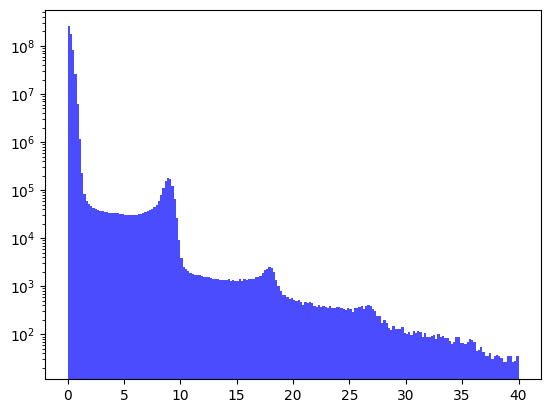

In [ ]:
hist, bin_edges = np.histogram(vals.ravel(), bins=200, range=(0, 40), density=None)

plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), color='blue', alpha=0.7, align='edge')
plt.yscale('log')

Indices:  [  0  44  88 132]


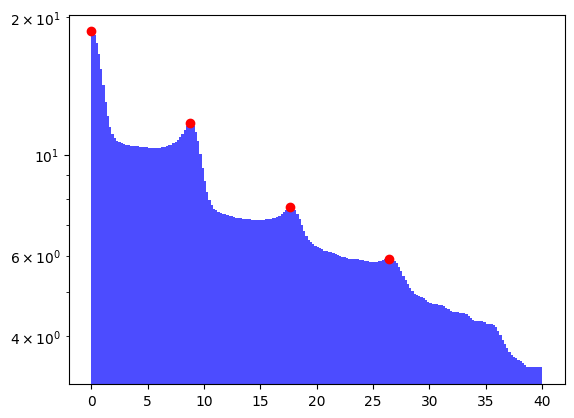

In [ ]:
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks

# Apply Gaussian filter to the histogram
soft_hist = gaussian_filter(np.log(hist), sigma=2)

# Find peaks in the filtered histogram
indices = find_peaks(soft_hist, distance=3, prominence=0.01, rel_height=0)[0]
indices = np.concatenate([[0], indices], axis=0)
print("Indices: ", indices)

plt.bar(bin_edges[:-1], soft_hist, width=np.diff(bin_edges), color='blue', alpha=0.7, align='edge')
plt.scatter(bin_edges[indices], soft_hist[indices], color='red', label='Peaks')
plt.yscale('log')

In [ ]:
print("AUD is", np.diff(bin_edges[indices]).mean())

AUD is 8.8
